# Predicting Irrigation Need

import pandas as pd

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder


## Load dataset

In [2]:
train = pd.read_csv('./playground-series-s6e4/train.csv')
test = pd.read_csv('./playground-series-s6e4/test.csv')
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [5]:
train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [6]:
train.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
for col in train.columns:
	if train[col].dtype == 'object':
		print(f"{col}: {train[col].nunique()} unique values")
		print(train[col].value_counts(), '\n------')

Soil_Type: 4 unique values
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64 
------
Crop_Type: 6 unique values
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64 
------
Crop_Growth_Stage: 4 unique values
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64 
------
Season: 3 unique values
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64 
------
Irrigation_Type: 4 unique values
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64 
------
Water_Source: 4 unique values
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64 
------
Mulching_Used: 2 unique values
Mulching_Used
No     316453


## Cleaning data for EDA:
- drop column id


In [8]:
test_id = test['id']
for data in [train, test]:
	data.drop(columns=['id'], inplace=True)

<Axes: >

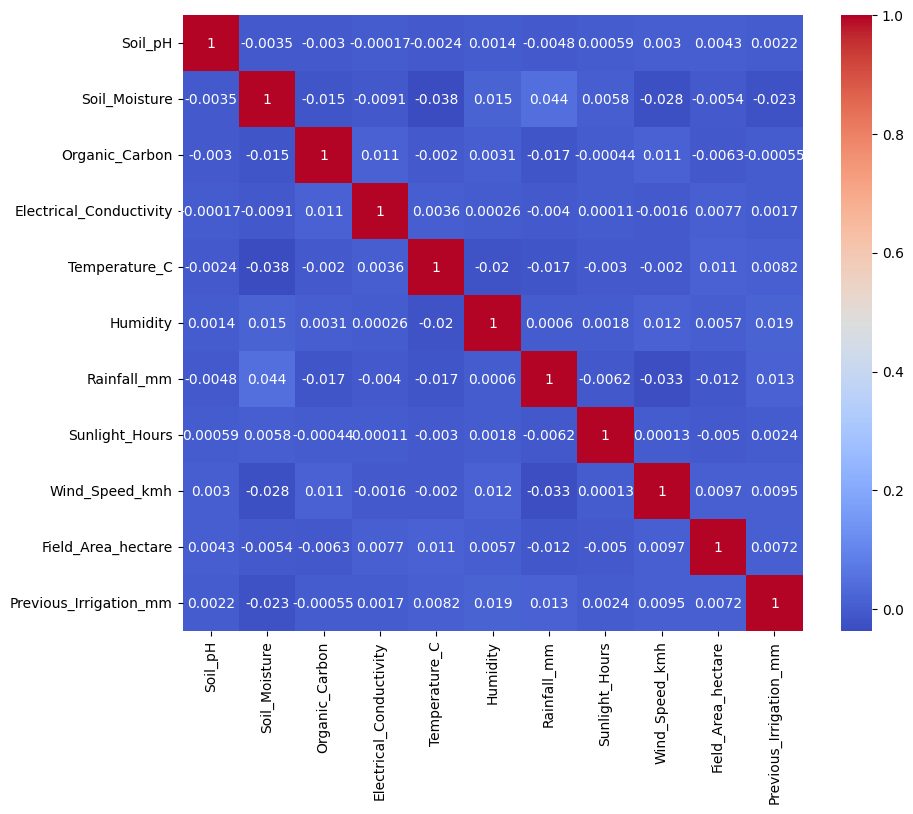

In [9]:
corr = train.corr(numeric_only=True)
figure, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ax=ax, data=corr, annot=True, cmap='coolwarm')

## Cleaning data for modelling

In [10]:
train.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [11]:
X = train.drop(columns=['Irrigation_Need'])
Y = train['Irrigation_Need']

In [12]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [13]:
for col in X_train.columns:
	if X_train[col].dtype == 'object':
		le_x = LabelEncoder()
		X_train[col] = le_x.fit_transform(X_train[col])
		X_val[col] = le_x.transform(X_val[col])
		test[col] = le_x.transform(test[col])

le_y = LabelEncoder()
Y_train = le_y.fit_transform(Y_train)
Y_val = le_y.transform(Y_val)

### A quick model

In [20]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_val)
print(classification_report(Y_val, Y_pred))
print(f"Balanced Accuracy Score: {balanced_accuracy_score(Y_val, Y_pred):.4f}")


              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4249
           1       0.98      0.98      0.98     73737
           2       0.96      0.96      0.96     48014

    accuracy                           0.97    126000
   macro avg       0.94      0.95      0.94    126000
weighted avg       0.97      0.97      0.97    126000

Balanced Accuracy Score: 0.9461


In [15]:
prediction = model.predict(test)
output = pd.DataFrame({'id': test_id, 'Irrigation_Need': le_y.inverse_transform(prediction)})
output.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [17]:
output.to_csv('submission1.csv', index=False)